# 2 softmax回归

## 网络架构
$\mathbf{o=Wx+b}$

## softmax运算
$$
\mathbf{\hat y}=\mathrm{softmax}(\mathbf o)\quad where\ \hat y_i=\frac{\exp (o_j)}{\sum_k\exp(o_k)}
$$

## 损失函数

### 对数似然

softmax函数给出了一个向量$\hat y$，我们可以将其视为“对给定任意输入$\mathbf x$的每个类的条件概率”。假设整个数据集$\{\mathbf {Y|X}\}$具有n个样本，其中索引i的样本由特征向量$x^{(i)}$和独热标签向量$y^{(i)}$组成。将估计值与实际值进行比较：
$$
P(\mathbf{Y|X})=\Pi_{i=1}^nP(\mathbf{y^{(i)}|x^{(i)}})
$$
最大似然估计，最大化$P(\mathbf {Y|X})$，相当于最小化负对数似然：
$$
-\log P(\mathbf{Y|X})=\sum_{i=1}^n-\log P(y^{(i)}|x^{(i)})=\sum_{i=1}^nl(\mathbf{y^{(i)}}, \hat y^{(i)})
$$

对于任何标签$\mathbf y$和模型预测$\hat y$，损失函数为
$$
l(\mathbf{y,\hat y})=-\sum_{j=1}^qy_j\log\hat y_j
$$

### softmax及其导数

$$
\partial_{o_j}l(\mathbf {y,\hat y})=\frac{\exp(o_j)}{\sum_{k=1}^q\exp(o_k)}-y_j=\mathrm{softmax(o)_j}-y_i
$$

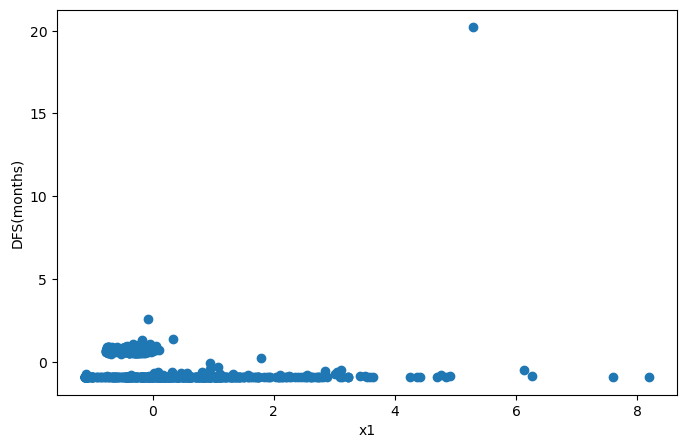

In [17]:
import sys
# sys.path.append('/home/kazundo/WorkSpace/Methods/bioinfo-dl-tutorial/src')
sys.path.append('/xjy/Project1/my_DeepLearnTest/bioinfo-dl-tutorial-main/src')

import torch
import matplotlib.pyplot as plt 
from data.loaders import load_bulk_drug_response
from utils.DL import DataIter, TryGpu
from utils.Plot import LossAndAccPlot

drug_mat = load_bulk_drug_response()
features = torch.tensor(drug_mat.data.values, device=TryGpu()).float()
labels = torch.tensor(drug_mat.target, device=TryGpu()).flatten()
features = (features - features.mean(dim=0))/ features.std(dim=0)
# features = features/ features.sum(dim=0)

plt.figure(figsize=(8, 5))
plt.scatter(features[:, 0].cpu().detach().numpy(), features[:, 1].cpu().detach().numpy())
plt.xlabel('x1')
plt.ylabel('DFS(months)')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =  train_test_split(features, labels ,test_size=0.3)

train_iter = DataIter(128, X_train, y_train)
test_iter = DataIter(128, X_test, y_test)

### 初始化模型参数

In [19]:
from torch import nn
net = nn.Sequential(nn.Linear(features.shape[1], 2))

def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.to(device=TryGpu())
net.apply(init_weight)

Sequential(
  (0): Linear(in_features=15963, out_features=2, bias=True)
)

### Softnax的问题

计算角度看，指数可能会造成数值稳定性问题。而softmax和交叉熵结合在一起抵消了，可以直接计算$o_j-\max(o_k)$

In [20]:
loss = nn.CrossEntropyLoss(reduction='mean')

### 优化算法

In [21]:
trainer = torch.optim.SGD(net.parameters(), lr=0.01)

### 训练

In [22]:

def train_model(net, train_iter, test_iter, loss, epochs, trainer):
    train_loss = []
    test_loss = []
    train_acc = []
    test_acc = []
    for epoch in range(epochs):
        net.train()
        loss_sum = 0
        crr = 0
        total = 0
        for X, y in train_iter:
            y_prob = net(X)
            l = loss(y_prob, y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
            with torch.no_grad():
                loss_sum += l.item() * y.size(0)
                crr += (y_prob.argmax(dim=1) == y).sum().item()
                total += y.size(0)
        train_loss.append(loss_sum/total)
        train_acc.append(crr/total)
        print(f'epoch:{epoch+1}\ntrain loss:{loss_sum/total:5f}\ttrain acc:{crr/total:.5f}')

        net.eval()
        loss_sum = 0
        crr = 0
        total = 0
        with torch.no_grad():
            for X, y in test_iter:
                y_prob = net(X)
                l = loss(y_prob, y)
                loss_sum += l.item() * y.size(0)
                crr += (y_prob.argmax(dim=1) == y).sum().item()
                total += y.size(0)
            test_loss.append(loss_sum/total)
            test_acc.append(crr/total)
            print(f'test  loss:{loss_sum/total:5f}\ttest  acc:{crr/total:.5f}')
    return net, train_loss, test_loss, train_acc, test_acc


In [ ]:
epochs = 1000
trainer = torch.optim.SGD(net.parameters(), lr=0.00005, weight_decay=100)
net, train_loss, test_loss, train_acc, test_acc = train_model(net, train_iter, test_iter, loss, epochs, trainer)

epoch:1
train loss:0.896971	train acc:0.53554
test  loss:0.781145	test  acc:0.52571
epoch:2
train loss:0.827467	train acc:0.52206
test  loss:0.759311	test  acc:0.51143
epoch:3
train loss:0.805677	train acc:0.52328
test  loss:0.747312	test  acc:0.51714
epoch:4
train loss:0.790209	train acc:0.52574
test  loss:0.737652	test  acc:0.52286
epoch:5
train loss:0.776518	train acc:0.53186
test  loss:0.728555	test  acc:0.52286
epoch:6
train loss:0.763401	train acc:0.53554
test  loss:0.721972	test  acc:0.54286
epoch:7
train loss:0.751450	train acc:0.54412
test  loss:0.713956	test  acc:0.51714
epoch:8
train loss:0.740771	train acc:0.54779
test  loss:0.707362	test  acc:0.53714
epoch:9
train loss:0.729739	train acc:0.55147
test  loss:0.701215	test  acc:0.52286
epoch:10
train loss:0.720561	train acc:0.56373
test  loss:0.695703	test  acc:0.55429
epoch:11
train loss:0.711488	train acc:0.57843
test  loss:0.690195	test  acc:0.54286
epoch:12
train loss:0.703354	train acc:0.57721
test  loss:0.685449	test  a

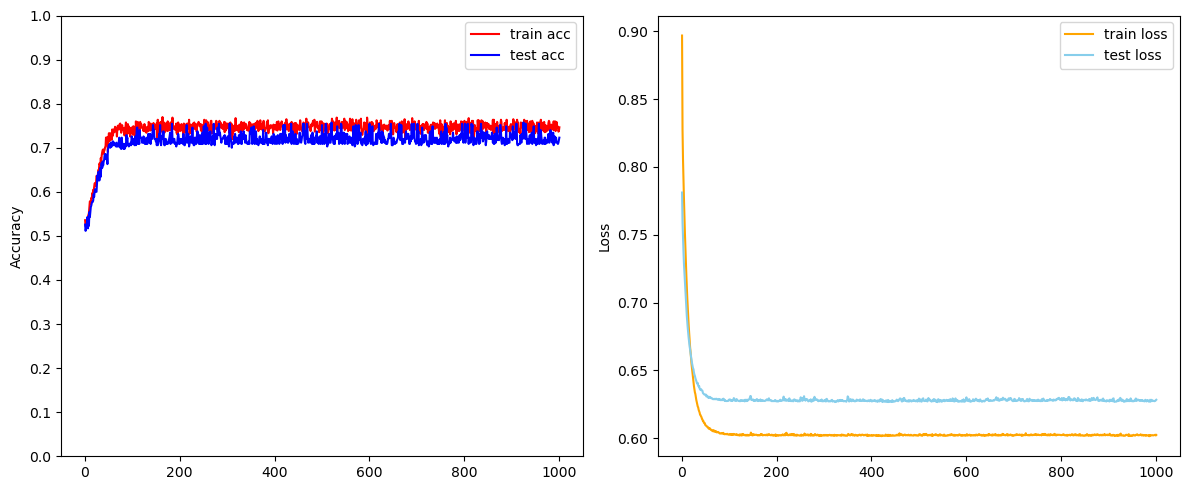

: 

: 

In [ ]:
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)